In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame({
    "Date": pd.date_range(start="2019-01-01", end="2021-12-31", freq="ME"),
    "Promotion_Spend": [300, 250, 400, 350, 450, 300, 200, 220, 270, 320, 300, 380] * 3,
    "Demand": [800, 750, 900, 850, 950, 780, 700, 720, 770, 810, 800, 880] +
              [820, 760, 920, 860, 960, 790, 710, 730, 780, 820, 810, 890] +
              [810, 740, 910, 840, 950, 770, 690, 710, 760, 800, 790, 870]
})

data.head()

,Date,Promotion_Spend,Demand
0,2019-01-31,300,800
1,2019-02-28,250,750
2,2019-03-31,400,900
3,2019-04-30,350,850
4,2019-05-31,450,950


In [3]:
X = data[["Promotion_Spend"]]
y = data["Demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [4]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.9823227330897455


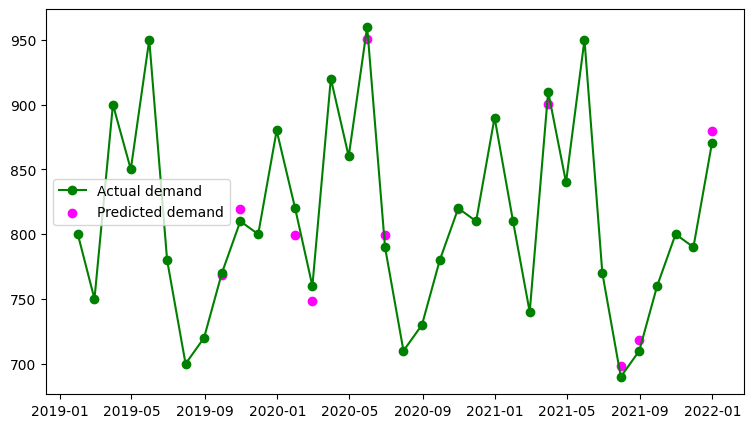

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(data["Date"], data["Demand"], color="green", marker="o", label="Actual demand")
plt.scatter(data["Date"][X_test.index], y_pred, color="magenta", label="Predicted demand")
plt.legend()
plt.show()

In [6]:
data["Month"] = data["Date"].dt.month
data = pd.get_dummies(data, columns=["Month"], drop_first=True)

data["Sine"] = np.sin(2 * np.pi * data["Date"].dt.month / 12)
data["Cosine"] = np.cos(2 * np.pi * data["Date"].dt.month / 12)


data.head()

,Date,Promotion_Spend,Demand,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Sine,Cosine
0,2019-01-31,300,800,False,False,False,False,False,False,False,False,False,False,False,0.500000,8.660254e-01
1,2019-02-28,250,750,True,False,False,False,False,False,False,False,False,False,False,0.866025,5.000000e-01
2,2019-03-31,400,900,False,True,False,False,False,False,False,False,False,False,False,1.000000,6.123234e-17
3,2019-04-30,350,850,False,False,True,False,False,False,False,False,False,False,False,0.866025,-5.000000e-01
4,2019-05-31,450,950,False,False,False,True,False,False,False,False,False,False,False,0.500000,-8.660254e-01


In [7]:
X = data.drop(columns=["Demand", "Date"])
y = data["Demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.9700920245398774


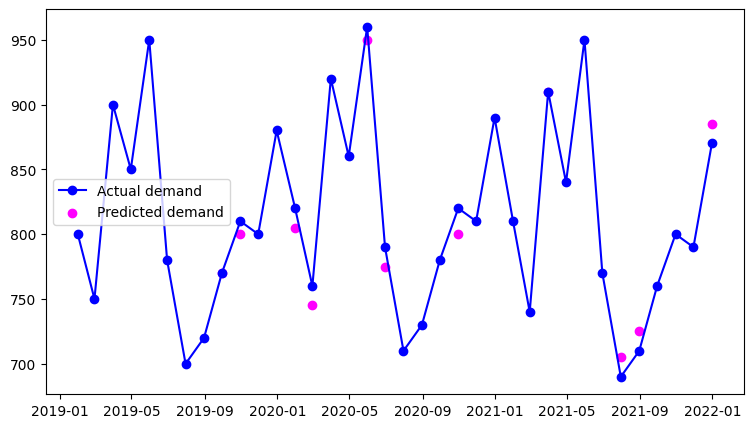

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(data["Date"], data["Demand"], color="blue", marker="o", label="Actual demand")
plt.scatter(data["Date"][X_test.index], y_pred, color="magenta", label="Predicted demand")
plt.legend()
plt.show()

Модель, яка не враховує сезонність, виявилася кращою за попередню. Прогноз R2 = 0,98.